In [1]:
import os
import re
import json
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)

/tmp/ipykernel_2805/97990642.py:15: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


In [2]:
PATH_INPUT = '../data/input/'
PATH_OUTPUT = '../data/output/'

---

#### **01 ) - Upload de dados**

---

##### **1.1 ) - _Upload dos dados sintéticos_**

In [3]:
def consolidar_jsons_sinteticos(caminho_diretorio: str) -> dict:
    dataset_consolidado = {}
    
    padrao_busca = os.path.join(caminho_diretorio, "*.json")
    arquivos_json = glob.glob(padrao_busca)
    
    if not arquivos_json:
        print(f"| Falha de leitura: Nenhum arquivo .json encontrado no diretório '{caminho_diretorio}'.")
        return dataset_consolidado

    for caminho_arquivo in arquivos_json:
        nome_arquivo = os.path.basename(caminho_arquivo)
        
        try:
            with open(caminho_arquivo, "r", encoding="utf-8") as arquivo:
                conteudo = json.load(arquivo)
                
                if isinstance(conteudo, dict):
                    dataset_consolidado.update(conteudo)
                else:
                    print(f"| Falha estrutural: O arquivo '{nome_arquivo}' não possui um dicionário na raiz. Ignorado.")
                    
        except json.JSONDecodeError:
            print(f"| Falha de parse: O arquivo '{nome_arquivo}' está corrompido ou não é um JSON válido.")
        except Exception as e:
            print(f"| Falha de I/O no arquivo '{nome_arquivo}': {e}")
            
    return dataset_consolidado

---

##### **1.2 ) - _Upload dos dados reais_**

In [4]:
def carregar_dados_reais(caminho: str) -> pd.DataFrame:
    try:
        with open(caminho, 'r', encoding='utf-8') as f:
            dados_json = json.load(f)
        
        df_prosper = pd.DataFrame(dados_json)
        return df_prosper
        
    except FileNotFoundError:
        print(f"| Falha de I/O: O arquivo '{caminho}' não foi encontrado.")
        return pd.DataFrame()
    except json.JSONDecodeError as e:
        print(f"| Falha de parse estrutural: O arquivo JSON contém erros de formatação na sintaxe. {e}")
        return pd.DataFrame()
    except ValueError as e:
        print(f"| Falha de conversão: Os dados carregados não formam uma estrutura tabular válida para o Pandas. {e}")
        return pd.DataFrame()

---

#### **02 ) - Execução do modelo de embeddings**

In [5]:
def padronizar_lexico(dic_variaveis):
    textos_padronizados = []
    labels_categorias = []

    for macro_classe, lista_vars in dic_variaveis.items():
        for var in lista_vars:
            texto_limpo = var.lower()
            texto_limpo = re.sub(r'_', ' ', texto_limpo)
            textos_padronizados.append(texto_limpo)
            labels_categorias.append(macro_classe)

    return textos_padronizados, labels_categorias

In [6]:
def calibrar_modelo_dominio(textos, labels, nome_modelo_base, epochs=5, batch_size=16):
    print(f"\nIniciando Fine-Tuning de Alta Repulsão: {nome_modelo_base}")
    dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
    # dispositivo = 'cpu'
    modelo = SentenceTransformer(nome_modelo_base, device=dispositivo, trust_remote_code=True)

    encoder = LabelEncoder()
    labels_int = encoder.fit_transform(labels)

    train_examples = []
    for texto, label in zip(textos, labels_int):
        train_examples.append(InputExample(texts=[texto], label=label))

    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=batch_size)

    train_loss = losses.BatchHardTripletLoss(
        model=modelo,
        distance_metric=losses.BatchHardTripletLossDistanceFunction.cosine_distance,
        margin=0.6
    )

    modelo.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=epochs,
        warmup_steps=int(len(train_dataloader) * 0.1),
        show_progress_bar=True
    )

    return modelo

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

def processar_e_plotar_modelos(dic_variaveis, lista_modelos):
    textos_limpos, labels = padronizar_lexico(dic_variaveis)
    n_modelos = len(lista_modelos)
    fig, axes = plt.subplots(1, n_modelos, figsize=(10 * n_modelos, 7))

    if n_modelos == 1:
        axes = [axes]

    modelo_final_calibrado = None

    for ax, nome_modelo in zip(axes, lista_modelos):
        modelo_calibrado = calibrar_modelo_dominio(textos_limpos, labels, nome_modelo)
        vetores = modelo_calibrado.encode(textos_limpos, show_progress_bar=False)

        try:
            sil_score = silhouette_score(vetores, labels)
            db_score = davies_bouldin_score(vetores, labels)
            ch_score = calinski_harabasz_score(vetores, labels)
            
            classes_unicas = np.unique(labels)
            sim_intraclasse_lista = []
            
            for c in classes_unicas:
                indices = [i for i, lbl in enumerate(labels) if lbl == c]
                if len(indices) > 1:
                    vetores_c = np.array(vetores)[indices]
                    sim_matrix = cosine_similarity(vetores_c)
                    pares_sim = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
                    if len(pares_sim) > 0:
                        sim_intraclasse_lista.append(np.mean(pares_sim))
            
            sim_intraclasse_media = np.mean(sim_intraclasse_lista) if sim_intraclasse_lista else 0.0
            
            titulo_metricas = (
                f"{nome_modelo}\n"
                f"Silhouette: {sil_score:.3f} | Davies-Bouldin: {db_score:.3f}\n"
                f"Calinski-Harabasz: {ch_score:.1f} | Cos. Intraclasse: {sim_intraclasse_media:.3f}"
            )
        except ValueError:
            titulo_metricas = f"{nome_modelo}\nFalha no cálculo de métricas estruturais"

        redutor = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        vetores_2d = redutor.fit_transform(vetores)

        df_plot = pd.DataFrame({
            'Componente 1': vetores_2d[:, 0],
            'Componente 2': vetores_2d[:, 1],
            'Macro Classe': labels
        })

        sns.scatterplot(
            data=df_plot, x='Componente 1', y='Componente 2',
            hue='Macro Classe', palette='tab20', s=100, ax=ax, alpha=0.8
        )

        ax.set_title(titulo_metricas, pad=15)
        ax.legend(title='Macro Classes', bbox_to_anchor=(1.05, 1), loc='upper left')

        modelo_final_calibrado = modelo_calibrado

    plt.tight_layout()
    plt.show()

    return modelo_final_calibrado, textos_limpos, labels

---

#### **03 ) - Classificador**

---

##### **3.1 ) - _Treinamento do classificador_**

In [23]:
def treinar_classificador(modelo_embeddings, textos_treino, labels_treino, modelo_classificador):
    """Treina um classificador injetado como dependência."""
    vetores_treino = modelo_embeddings.encode(textos_treino, show_progress_bar=False)

    encoder = LabelEncoder()
    y_treino = encoder.fit_transform(labels_treino)

    modelo_classificador.fit(vetores_treino, y_treino)

    return modelo_classificador, encoder

In [24]:
def predict_lote(textos, modelo_embeddings, classificador, encoder, limiar_confianca=0.50):
    vetores_entrada = modelo_embeddings.encode(textos.tolist(), show_progress_bar=False)
    probabilidades_todas = classificador.predict_proba(vetores_entrada)
    
    indices_vencedores = np.argmax(probabilidades_todas, axis=1)
    probabilidades_vencedoras = np.max(probabilidades_todas, axis=1)
    
    classes_finais = encoder.inverse_transform(indices_vencedores)
    
    resultados = []
    for prob, classe in zip(probabilidades_vencedoras, classes_finais):
        if prob < limiar_confianca:
            resultados.append({
                "classe_predita": "UNCLASSIFIED",
                "confianca": float(prob),
                "alerta": f"Rejeitado (Limiar: {limiar_confianca})"
            })
        else:
            resultados.append({
                "classe_predita": classe,
                "confianca": float(prob),
                "alerta": None
            })
            
    return pd.DataFrame(resultados)

---

##### **3.2 ) - _Gerar uma predição_**

In [10]:
def predict_individual(texto, modelo_embeddings, classificador, encoder, limiar_confianca=0.50):
    """Realiza a inferência para uma única string isolada."""
    
    vetor_entrada = modelo_embeddings.encode([texto], show_progress_bar=False)
    
    probabilidades = classificador.predict_proba(vetor_entrada)[0]
    
    indice_vencedor = np.argmax(probabilidades)
    probabilidade_vencedora = probabilidades[indice_vencedor]
    
    if probabilidade_vencedora < limiar_confianca:
        return {
            "classe_predita": "UNCLASSIFIED",
            "confianca": float(probabilidade_vencedora),
            "alerta": f"Rejeitado pela trava de segurança (Limiar: {limiar_confianca})"
        }
        
    classe_final = encoder.inverse_transform([indice_vencedor])[0]
    
    return {
        "classe_predita": classe_final,
        "confianca": float(probabilidade_vencedora),
        "alerta": None
    }

In [11]:
def avaliar_modelos(dicionario_modelos, modelo_embeddings, textos_base, labels_base, df_consolidado, limiar_confianca=0.50):
    """Itera sobre múltiplos modelos, treina, prediz e consolida métricas."""
    relatorios = {}
    
    y_real = df_consolidado['macro_class']
    textos_teste = df_consolidado['desc']
    
    for nome, classificador_base in dicionario_modelos.items():
        print(f"\n| Iniciando avaliação: {nome}")
        
        modelo_treinado, encoder = treinar_classificador(
            modelo_embeddings, textos_base, labels_base, classificador_base
        )
        
        df_resultados = predict_lote(
            textos_teste, modelo_embeddings, modelo_treinado, encoder, limiar_confianca
        )
        
        y_pred = df_resultados['classe_predita']
        
        media_confianca = df_resultados['confianca'].mean()
        
        acuracia = accuracy_score(y_real, y_pred)
        relatorio = classification_report(y_real, y_pred, zero_division=0)
        
        print(f"| Acurácia Global ({nome}): {acuracia:.4f}")
        print(f"| Média de Confiança ({nome}): {media_confianca:.4f}")
        
        relatorios[nome] = {
            "acuracia": acuracia,
            "media_confianca": media_confianca,
            "relatorio": relatorio,
            "modelo": modelo_treinado,
            "encoder": encoder
        }
        
    return relatorios

---

#### **04 ) - Execução**


Iniciando Fine-Tuning de Alta Repulsão: BAAI/bge-large-en-v1.5


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


/home/andre/miniconda3/envs/sematic/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


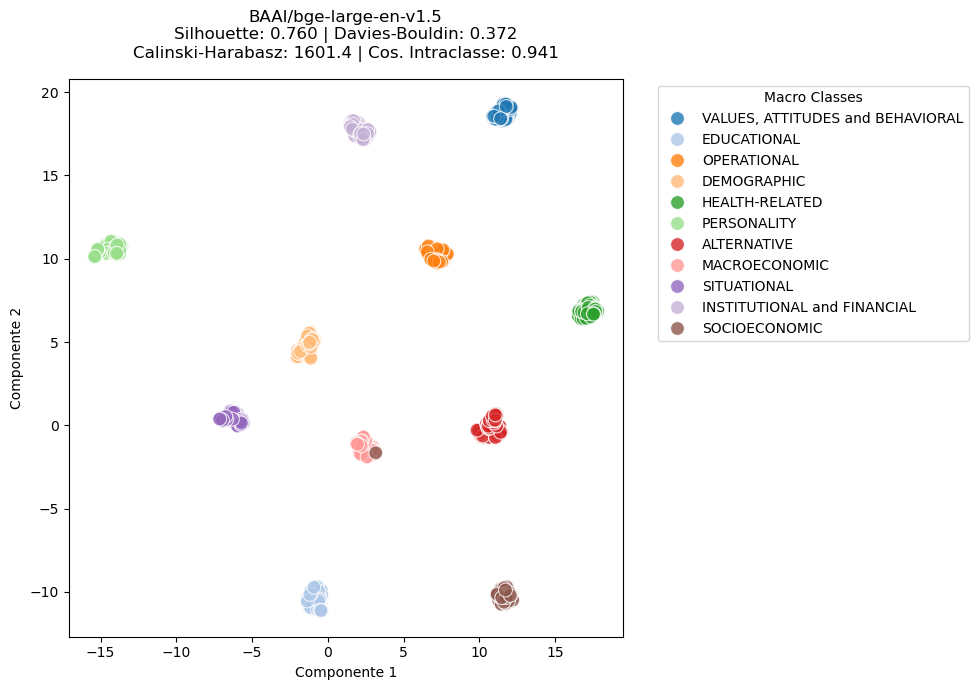

In [12]:
modelos_alvo = ['BAAI/bge-large-en-v1.5']
b = ['BAAI/bge-large-en-v1.5']
a = ['Alibaba-NLP/gte-large-en-v1.5']
e = ['intfloat/e5-large-v2']
dados = consolidar_jsons_sinteticos("../data/output/SynteticData")
modelo_embeddings, textos_base, labels_base = processar_e_plotar_modelos(dados, modelos_alvo)

---

#### **05 ) - Avaliação com dados reais**

In [33]:
modelos_para_testar = {
    "Regressao_Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM_Linear": SVC(kernel='linear', probability=True, random_state=42)
}

---

##### **5.1 ) - _Criando dataset de teste_**

In [34]:
df_teste_1 = pd.read_csv(PATH_INPUT + 'cv_adult.csv')
df_teste_2 = pd.read_csv(PATH_INPUT + 'cv_hmda_2017.csv')
df_teste_3 = pd.read_csv(PATH_INPUT + 'cv_prosperLoanData.csv')
df_teste = pd.concat([df_teste_1,df_teste_2,df_teste_3], ignore_index=True)

---

##### **5.1 ) - _Executando a avaliação - Adult Dataset_**

In [35]:
resultados_finais = avaliar_modelos(
    dicionario_modelos=modelos_para_testar,
    modelo_embeddings=modelo_embeddings,
    textos_base=textos_base,
    labels_base=labels_base,
    df_consolidado=df_teste_1,
    limiar_confianca=0.1
)


| Iniciando avaliação: Regressao_Logistica
| Acurácia Global (Regressao_Logistica): 0.6000
| Média de Confiança (Regressao_Logistica): 0.6909

| Iniciando avaliação: Random_Forest
| Acurácia Global (Random_Forest): 0.6667
| Média de Confiança (Random_Forest): 0.5993

| Iniciando avaliação: SVM_Linear
| Acurácia Global (SVM_Linear): 0.6667
| Média de Confiança (SVM_Linear): 0.6655


---

##### **5.2 ) - _Executando a avaliação - HMDA 2017_**

In [41]:
resultados_finais = avaliar_modelos(
    dicionario_modelos=modelos_para_testar,
    modelo_embeddings=modelo_embeddings,
    textos_base=textos_base,
    labels_base=labels_base,
    df_consolidado=df_teste_2,
    limiar_confianca=0.1
)


| Iniciando avaliação: Regressao_Logistica
| Acurácia Global (Regressao_Logistica): 0.5333
| Média de Confiança (Regressao_Logistica): 0.7146

| Iniciando avaliação: Random_Forest
| Acurácia Global (Random_Forest): 0.5667
| Média de Confiança (Random_Forest): 0.5660

| Iniciando avaliação: SVM_Linear
| Acurácia Global (SVM_Linear): 0.5333
| Média de Confiança (SVM_Linear): 0.7021


---

##### **5.3 ) - _Executando a avaliação - Prosper Loan Data_**

In [37]:
resultados_finais = avaliar_modelos(
    dicionario_modelos=modelos_para_testar,
    modelo_embeddings=modelo_embeddings,
    textos_base=textos_base,
    labels_base=labels_base,
    df_consolidado=df_teste_3,
    limiar_confianca=0.1
)


| Iniciando avaliação: Regressao_Logistica
| Acurácia Global (Regressao_Logistica): 0.7654
| Média de Confiança (Regressao_Logistica): 0.8839

| Iniciando avaliação: Random_Forest
| Acurácia Global (Random_Forest): 0.7531
| Média de Confiança (Random_Forest): 0.8578

| Iniciando avaliação: SVM_Linear
| Acurácia Global (SVM_Linear): 0.7531
| Média de Confiança (SVM_Linear): 0.8603


---

##### **5.4 ) - _Executando a avaliação final - Prosper Loan + HMDA + Adult_**

In [38]:
resultados_finais = avaliar_modelos(
    dicionario_modelos=modelos_para_testar,
    modelo_embeddings=modelo_embeddings,
    textos_base=textos_base,
    labels_base=labels_base,
    df_consolidado=df_teste,
    limiar_confianca=0.1
)


| Iniciando avaliação: Regressao_Logistica
| Acurácia Global (Regressao_Logistica): 0.6905
| Média de Confiança (Regressao_Logistica): 0.8206

| Iniciando avaliação: Random_Forest
| Acurácia Global (Random_Forest): 0.6984
| Média de Confiança (Random_Forest): 0.7575

| Iniciando avaliação: SVM_Linear
| Acurácia Global (SVM_Linear): 0.6905
| Média de Confiança (SVM_Linear): 0.7994


In [39]:
print("\n| RESUMO FINAL")
for nome, metricas in resultados_finais.items():
    print(f"\nModelo: {nome}")
    print(f"Acurácia: {metricas['acuracia']:.4f}")
    print(metricas['relatorio'])


| RESUMO FINAL

Modelo: Regressao_Logistica
Acurácia: 0.6905
                                  precision    recall  f1-score   support

                     ALTERNATIVE       0.00      0.00      0.00        10
                     DEMOGRAPHIC       0.64      0.78      0.70         9
     INSTITUTIONAL and FINANCIAL       0.72      0.94      0.82        64
                   MACROECONOMIC       0.75      0.50      0.60         6
                     OPERATIONAL       0.69      0.53      0.60        17
                     SITUATIONAL       0.00      0.00      0.00         0
                   SOCIOECONOMIC       0.62      0.44      0.52        18
VALUES, ATTITUDES and BEHAVIORAL       0.00      0.00      0.00         2

                        accuracy                           0.69       126
                       macro avg       0.43      0.40      0.40       126
                    weighted avg       0.63      0.69      0.65       126


Modelo: Random_Forest
Acurácia: 0.6984
       

---

#### **06 ) - Gerador de predições unitárias**

In [42]:
input_teste = """The borrower indicated they have the required documentation to support their income."""

In [43]:
modelo_escolhido = resultados_finais['Regressao_Logistica']['modelo']
encoder_escolhido = resultados_finais['Regressao_Logistica']['encoder']

resultado_unico = predict_individual(
    texto=input_teste,
    modelo_embeddings=modelo_embeddings,
    classificador=modelo_escolhido,
    encoder=encoder_escolhido,
    limiar_confianca=0.50
)

print(f"\n| Input: '{input_teste}'")
print(f"| Predição: {resultado_unico['classe_predita']} - Confiança: {resultado_unico['confianca']:.2f}")
if resultado_unico['alerta']:
    print(f"| Alerta: {resultado_unico['alerta']}")


| Input: 'The borrower indicated they have the required documentation to support their income.'
| Predição: SOCIOECONOMIC - Confiança: 0.80


In [ ]:
import umap.umap_ as umap
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plotar_sobreposicao_dominios_comparativo(modelo_embeddings, textos_treino, labels_treino, textos_teste, labels_teste):
    """
    Gera dois scatter plots 2D lado a lado utilizando UMAP para visualizar a sobreposição 
    entre os dados sintéticos (treino) e empíricos (teste).
    - Gráfico 1 foca na preservação local (agrupamento de vizinhos).
    - Gráfico 2 foca na preservação global (distanciamento real entre macroclasses).
    """
    print("| Extraindo embeddings dos dados de treino e teste...")
    
    vetores_treino = modelo_embeddings.encode(textos_treino, show_progress_bar=False)
    
    if isinstance(textos_teste, pd.Series):
        textos_teste = textos_teste.tolist()
    vetores_teste = modelo_embeddings.encode(textos_teste, show_progress_bar=False)
    
    vetores_completos = np.vstack((vetores_treino, vetores_teste))
    labels_completos = np.concatenate((labels_treino, labels_teste))
    
    origem = ['Sintético (Treino)'] * len(labels_treino) + ['Empírico (Teste)'] * len(labels_teste)
    
    print("| Aplicando redução de dimensionalidade (UMAP - Local)...")
    redutor_local = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    vetores_2d_local = redutor_local.fit_transform(vetores_completos)
    
    print("| Aplicando redução de dimensionalidade (UMAP - Global)...")
    redutor_global = umap.UMAP(n_components=2, n_neighbors=100, min_dist=0.1, init='pca', random_state=42)
    vetores_2d_global = redutor_global.fit_transform(vetores_completos)
    
    df_local = pd.DataFrame({
        'Componente 1': vetores_2d_local[:, 0],
        'Componente 2': vetores_2d_local[:, 1],
        'Macro Classe': labels_completos,
        'Origem': origem
    })
    
    df_global = pd.DataFrame({
        'Componente 1': vetores_2d_global[:, 0],
        'Componente 2': vetores_2d_global[:, 1],
        'Macro Classe': labels_completos,
        'Origem': origem
    })
    
    print("| Gerando visualizações...")
    
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    
    # --- Plot 1: Topologia Local ---
    sns.scatterplot(
        data=df_local, x='Componente 1', y='Componente 2',
        hue='Macro Classe', style='Origem', palette='tab20', 
        s=80, alpha=0.75, ax=axes[0]
    )
    axes[0].set_title("UMAP (Topologia Local): n_neighbors=15", pad=15, fontsize=14)
    axes[0].get_legend().remove()
    
    # --- Plot 2: Topologia Global ---
    sns.scatterplot(
        data=df_global, x='Componente 1', y='Componente 2',
        hue='Macro Classe', style='Origem', palette='tab20', 
        s=80, alpha=0.75, ax=axes[1]
    )
    axes[1].set_title("UMAP (Topologia Global): n_neighbors=100 | init='pca'", pad=15, fontsize=14)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Macro Classes & Origem")
    
    # Título Geral
    plt.suptitle("Validação Geométrica: Treino Sintético vs. Teste Empírico", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

| Extraindo embeddings dos dados de treino e teste...
| Aplicando redução de dimensionalidade (UMAP - Local)...


/home/andre/miniconda3/envs/sematic/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


| Aplicando redução de dimensionalidade (UMAP - Global)...


/home/andre/miniconda3/envs/sematic/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


| Gerando visualizações...


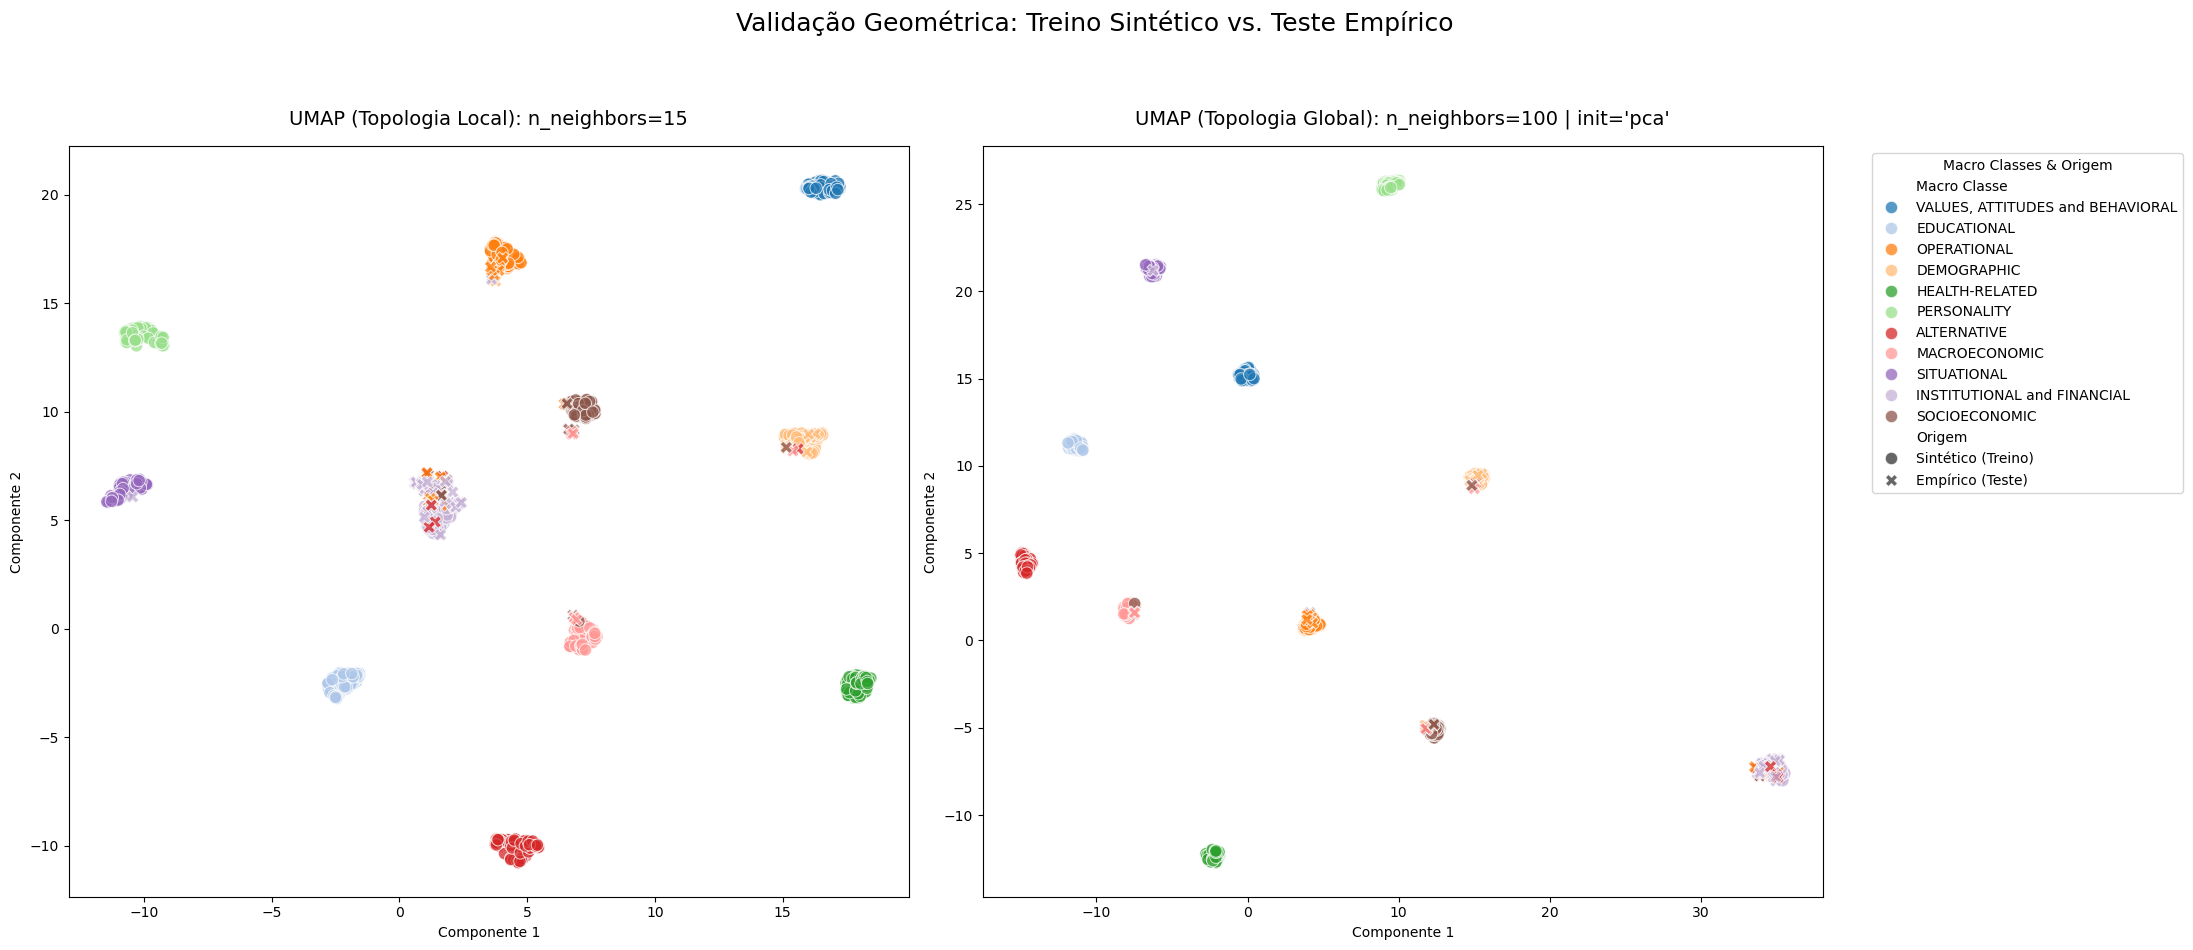

In [51]:
plotar_sobreposicao_dominios_comparativo(
    modelo_embeddings=modelo_embeddings,
    textos_treino=textos_base,
    labels_treino=labels_base,
    textos_teste=df_teste['desc'],
    labels_teste=df_teste['macro_class']
)

In [46]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def detalhar_acertos_erros(y_real, y_pred):
    """
    Desmembra a Matriz de Confusão para listar o volume absoluto de acertos, 
    omissões e alarmes falsos por macroclasse.
    """
    labels_unicas = sorted(list(set(y_real) | set(y_pred)))
    cm = confusion_matrix(y_real, y_pred, labels=labels_unicas)
    
    acertos = np.diag(cm)
    erros_omissao = cm.sum(axis=1) - acertos     
    erros_alarme_falso = cm.sum(axis=0) - acertos
    total_real = cm.sum(axis=1)
    
    df_analise = pd.DataFrame({
        'Macro Classe': labels_unicas,
        'Volume Real': total_real,
        'Acertos': acertos,
        'Erros (Omissões / FN)': erros_omissao,
        'Erros (Alarmes Falsos / FP)': erros_alarme_falso
    })
    
    df_analise['Taxa de Acerto (%)'] = np.where(total_real > 0, (acertos / total_real) * 100, 0.0)
    
    df_analise = df_analise.sort_values(by=['Taxa de Acerto (%)', 'Erros (Omissões / FN)'], ascending=[True, False])
    
    return df_analise

def plotar_matriz_confusao(y_real, y_pred):
    """
    Renderiza a topologia dos erros em um Heatmap para inspeção visual do vazamento.
    """
    labels_unicas = sorted(list(set(y_real) | set(y_pred)))
    cm = confusion_matrix(y_real, y_pred, labels=labels_unicas)
    
    plt.figure(figsize=(12, 9))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Reds', 
        xticklabels=labels_unicas, yticklabels=labels_unicas,
        linewidths=.5, cbar_kws={"shrink": .75}
    )
    plt.xlabel('Classe Predita (O que o modelo achou que era)', fontsize=12, labelpad=15)
    plt.ylabel('Classe Real (Ground Truth)', fontsize=12, labelpad=15)
    plt.title('Matriz de Confusão: Mapeamento de Vazamento entre Classes', pad=20, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

| Auditando erros da Regressão Logística...


/tmp/ipykernel_2805/2639474416.py:28: RuntimeWarning: invalid value encountered in divide
  df_analise['Taxa de Acerto (%)'] = np.where(total_real > 0, (acertos / total_real) * 100, 0.0)


,Macro Classe,Volume Real,Acertos,Erros (Omissões / FN),Erros (Alarmes Falsos / FP),Taxa de Acerto (%)
0,ALTERNATIVE,10,0,10,0,0.000000
7,"VALUES, ATTITUDES and BEHAVIORAL",2,0,2,0,0.000000
5,SITUATIONAL,0,0,0,2,0.000000
6,SOCIOECONOMIC,18,8,10,5,44.444444
3,MACROECONOMIC,6,3,3,1,50.000000
4,OPERATIONAL,17,9,8,4,52.941176
1,DEMOGRAPHIC,9,7,2,4,77.777778
2,INSTITUTIONAL and FINANCIAL,64,60,4,23,93.750000


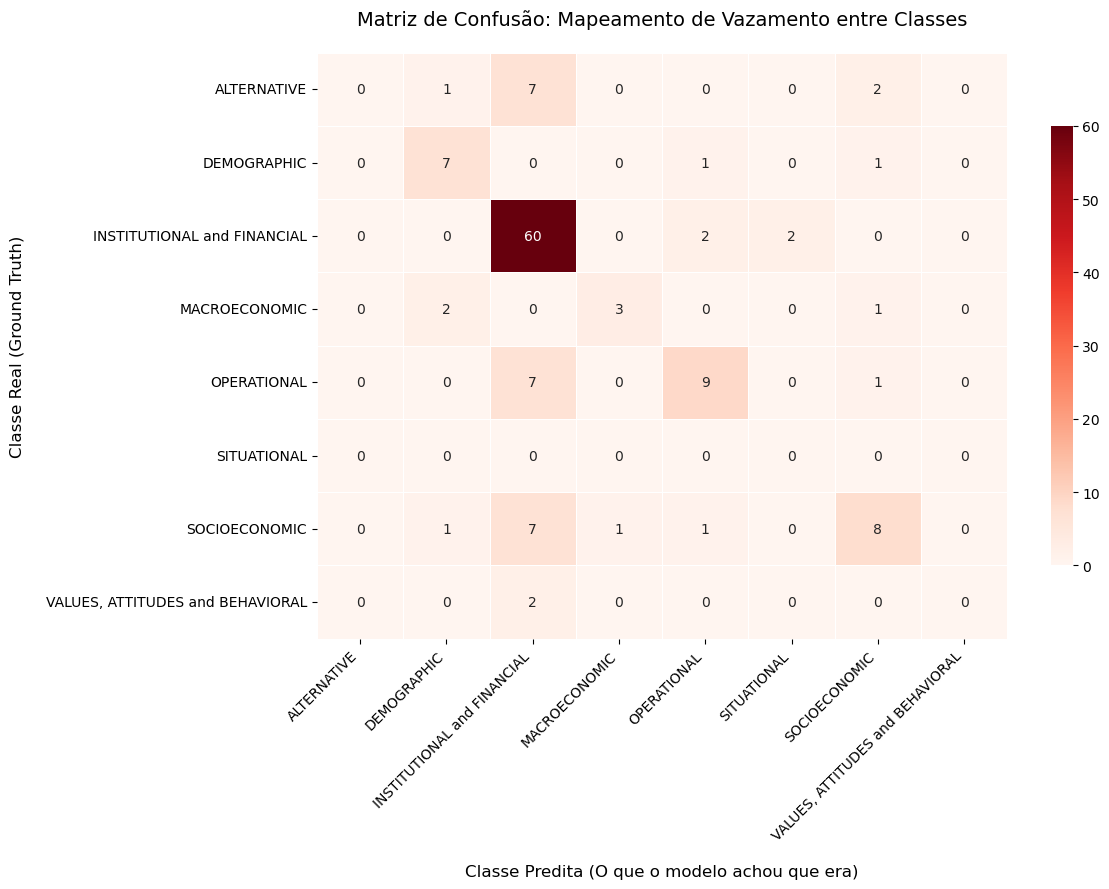

In [47]:
print("| Auditando erros da Regressão Logística...")

modelo_alvo = resultados_finais['Regressao_Logistica']['modelo']
encoder_alvo = resultados_finais['Regressao_Logistica']['encoder']

df_resultados_auditoria = predict_lote(
    df_teste['desc'], 
    modelo_embeddings, 
    modelo_alvo, 
    encoder_alvo, 
    limiar_confianca=0.0
)

y_real = df_teste['macro_class']
y_pred = df_resultados_auditoria['classe_predita']

df_detalhamento = detalhar_acertos_erros(y_real, y_pred)
display(df_detalhamento)

plotar_matriz_confusao(y_real, y_pred)